In [2]:
!conda list dolfin

# packages in environment at /home/fes33/miniforge3/envs/fenicsx:
#
# Name                     Version          Build              Channel
fenics-dolfinx             0.10.0           py311h738bb83_101  conda-forge
fenics-libdolfinx          0.10.0           py311h7b9e3d9_101  conda-forge


In [5]:
import dolfinx

print(
    f"DOLFINx version: {dolfinx.__version__} based on GIT commit: {dolfinx.git_commit_hash} of https://github.com/FEniCS/dolfinx/"
)

from mpi4py import MPI
from dolfinx import mesh
import numpy

domain = mesh.create_unit_square(MPI.COMM_WORLD, 8, 8, mesh.CellType.quadrilateral)

DOLFINx version: 0.10.0 based on GIT commit: d31f333cac3a2e24d8d17093e50a10f2b5a80a9a of https://github.com/FEniCS/dolfinx/


In [6]:
from dolfinx import fem

V = fem.functionspace(domain, ("Lagrange", 1))

In [7]:
uD = fem.Function(V)
uD.interpolate(lambda x: 1 + x[0] ** 2 + 2 * x[1] ** 2)

In [8]:
tdim = domain.topology.dim
fdim = tdim - 1
domain.topology.create_connectivity(fdim, tdim)
boundary_facets = mesh.exterior_facet_indices(domain.topology)

In [9]:
boundary_dofs = fem.locate_dofs_topological(V, fdim, boundary_facets)
bc = fem.dirichletbc(uD, boundary_dofs)

In [10]:
import ufl

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

In [11]:
from dolfinx import default_scalar_type

f = fem.Constant(domain, default_scalar_type(-6))

In [12]:
a = ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx
L = f * v * ufl.dx

In [13]:
from dolfinx.fem.petsc import LinearProblem

problem = LinearProblem(
    a,
    L,
    bcs=[bc],
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
    petsc_options_prefix="Poisson",
)
uh = problem.solve()

In [14]:
V2 = fem.functionspace(domain, ("Lagrange", 2))
uex = fem.Function(V2, name="u_exact")
uex.interpolate(lambda x: 1 + x[0] ** 2 + 2 * x[1] ** 2)

In [15]:
L2_error = fem.form(ufl.inner(uh - uex, uh - uex) * ufl.dx)
error_local = fem.assemble_scalar(L2_error)
error_L2 = numpy.sqrt(domain.comm.allreduce(error_local, op=MPI.SUM))

In [16]:
error_max = numpy.max(numpy.abs(uD.x.array - uh.x.array))
if domain.comm.rank == 0:  # Only print the error on one process
    print(f"Error_L2 : {error_L2:.2e}")
    print(f"Error_max : {error_max:.2e}")

Error_L2 : 8.24e-03
Error_max : 3.55e-15


In [17]:
import pyvista

print(pyvista.global_theme.jupyter_backend)

trame


In [18]:
from dolfinx import plot

domain.topology.create_connectivity(tdim, tdim)
topology, cell_types, geometry = plot.vtk_mesh(domain, tdim)
grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)

/home/fes33/miniforge3/envs/fenicsx/lib/python3.11/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


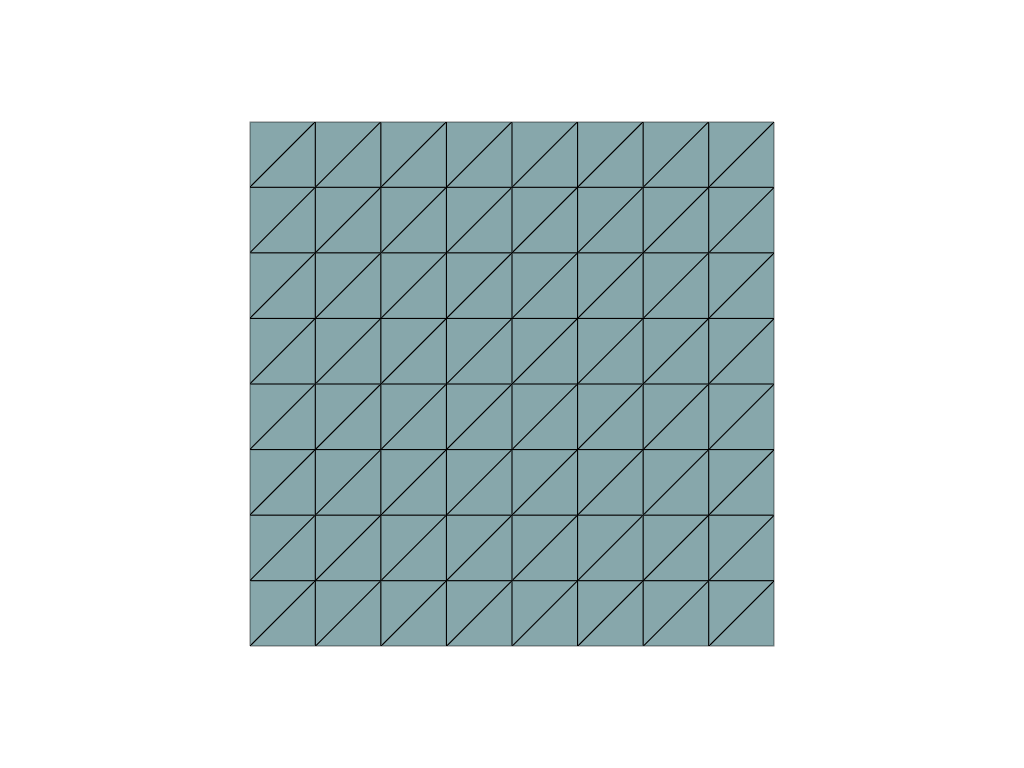

In [19]:
plotter = pyvista.Plotter()
plotter.add_mesh(grid, show_edges=True)
plotter.view_xy()
if not pyvista.OFF_SCREEN:
    plotter.show()
else:
    figure = plotter.screenshot("fundamentals_mesh.png")